## Clone Flow-Bench and Prepare the Python Environment

In [ ]:
# do NOT run this cell on your local PC

# Clone Flow-Bench
!rm -rf /content/Flow-Bench
!git clone https://github.com/Qi-Zhou-Geo/Flow-Bench.git
%cd Flow-Bench

In [ ]:
# do NOT run this cell on your local PC

# Install dependencies (pip equivalents), this will take a while
!pip install -r config/Flow-Bench-env.txt

# use the conda for local PC
# conda env create -f config/Flow-Bench-env.yml

## Importing modules

In [1]:
#!/usr/bin/python
# -*- coding: UTF-8 -*-

#__modification time__ = 2026-01-20
#__author__ = Qi Zhou, Helmholtz Centre Potsdam - GFZ German Research Centre for Geosciences
#__find me__ = qi.zhou@gfz.de, qi.zhou.geo@gmail.com, https://github.com/Qi-Zhou-Geo
# Please do not distribute this code without the author's permission

from obspy.core import UTCDateTime
from obspy.clients.fdsn import Client

import scipy.signal
import scipy.signal.windows
# Patch missing top-level windows
scipy.signal.hann = scipy.signal.windows.hann
scipy.signal.hamming = scipy.signal.windows.hamming
scipy.signal.blackman = scipy.signal.windows.blackman
scipy.signal.flattop = scipy.signal.windows.flattop


# <editor-fold desc="add the sys.path to search for custom modules">
import os
import sys
from pathlib import Path

# Check if running in Colab
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    # Google Colab - mount drive first
    from google.colab import drive
    drive.mount('/content/drive')

    current_dir = Path.cwd()
    if "demo" in os.listdir():
      project_root = Path(current_dir).parent
    else:
      print("Please check the project path.")
else:
    current_dir = "/Users/qizhou/#python/Flow-Bench/demo"
    project_root = "/Users/qizhou/#python/Flow-Bench"


sys.path.append(str(project_root))
print(f"Current dir: {current_dir}\n"
      f"Project root: {project_root}")
# </editor-fold>

# import the custom functions
from functions.model import FlowBench

/usr/local/Caskroom/mambaforge/base/envs/flow-bench/lib/python3.11/site-packages/obspy/core/util/base.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Current dir: /Users/qizhou/#python/Flow-Bench/demo
Project root: /Users/qizhou/#python/Flow-Bench


## Fetch some seismic signals

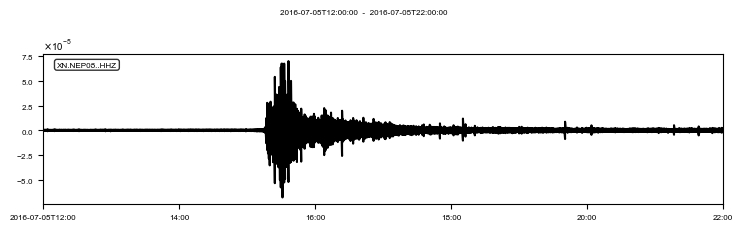

               network: XN
               station: NEP08
              location: 
               channel: HHZ
             starttime: 2016-07-05T12:00:00.000000Z
               endtime: 2016-07-05T22:00:00.000000Z
         sampling_rate: 200.0
                 delta: 0.005
                  npts: 7200001
                 calib: 1.0
_fdsnws_dataselect_url: http://geofon.gfz-potsdam.de/fdsnws/dataselect/1/query
               _format: MSEED
                 mseed: AttribDict({'dataquality': 'D', 'number_of_records': 5143, 'encoding': 'STEIM1', 'byteorder': '>', 'record_length': 4096, 'filesize': 21065728})
            processing: ['ObsPy 1.4.0: trim(endtime=UTCDateTime(2016, 7, 6, 0, 0)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2016, 7, 5, 10, 0))', "ObsPy 1.4.0: detrend(options={}::type='linear')", "ObsPy 1.4.0: detrend(options={}::type='demean')", "ObsPy 1.4.0: taper(max_length=None::max_percentage=0.05::side='both'::type='hann')", "ObsPy 1.4.0: remove_res

In [2]:
client = Client("GEOFON")

network, station, location, channel = "XN", "NEP08", "", "HHZ"
starttime = UTCDateTime("2016-07-05T10:00:00")
endtime = UTCDateTime("2016-07-06T00:00:00")

inventory = client.get_stations(network=network, station=station, location=location, channel=channel,
                                starttime=starttime, endtime=endtime, level="response")

st = client.get_waveforms(network=network, station=station, location=location, channel=channel,
                          starttime=starttime, endtime=endtime)

st.merge(method=1, fill_value='latest', interpolation_samples=0)
st._cleanup()
st.detrend("linear")
st.detrend("demean")
st.taper(max_percentage=0.05)
st.remove_response(inventory=inventory, output="VEL", pre_filt=(0.5, 1, 50, 55), water_level=60)
st.filter("bandpass", freqmin=1.0, freqmax=50)
st.detrend("linear")
st.detrend("demean")
st.taper(max_percentage=0.05)
st.trim(starttime + 2 * 3600, endtime - 2 * 3600)


st.plot()
print(st[0].stats)

## Have Fun with Flow-Bench

Event Start Time: 2016-07-05T15:16:27
Event End Time: 2016-07-05T17:07:47

Event End Time: 2016-07-05T15:42:48

Freq. Domain:
       parameter  Fitting from 1.00 to Peak Frequency 5.90 Hz  Fitting from Peak Frequency 5.90 to 50 Hz
            beta                                         7.15                                      -4.53
beta_95%CI_lower                                         6.84                                       -4.6
beta_95%CI_upper                                         7.45                                      -4.46
       intercept                                         -164                                      -73.3
      s_residual                                         2.28                                       1.79
       r_squared                                        0.979                                      0.974
         p_value                                     8.48e-42                                          0
       peak_freq                  

<Figure size 640x480 with 0 Axes>

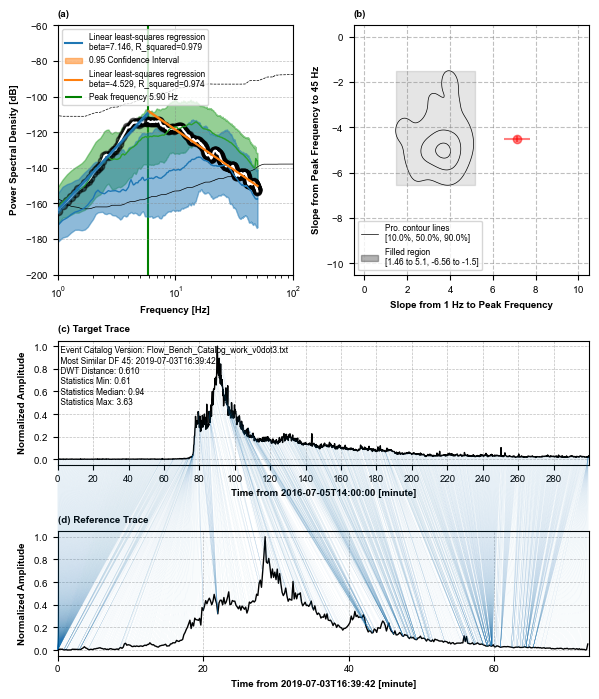

In [3]:
model_version = "0.3"
model = FlowBench(model_version=model_version, output_path=current_dir)
model.define_event_timing(st)

# use the STA/LTA based timing
event_start, event_end = "2016-07-05T15:16:27", "2016-07-05T17:07:48"
model.freq_domain(st, event_start, event_end)

# use the more data to cover the slient period
event_start, event_end = "2016-07-05T14:00:00", "2016-07-05T19:00:00"
model.time_domain(st, event_start, event_end)
model.plot()